<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Deep Learning and Reinforcement Learning**

## Modul 2: BackPropagation Training and Keras
### Demo: Backpropagation

Estimasi waktu yang dibutuhkan: **30** menit

Selamat datang di demo algoritma **Backpropagation**! Dalam lab ini, kita akan membangun dan melatih *Multi-Layer Perceptron* (MLP) sederhana dengan satu lapisan tersembunyi (*hidden layer*). Kita akan mengimplementasikan seluruh prosesnya menggunakan pustaka **NumPy** agar Anda dapat memahami mekanisme di balik layar dari proses pembelajaran jaringan saraf tiruan.

## Daftar Isi

<ol>
    <li><a href="#Objectives">Tujuan Pembelajaran</a></li>
    <li>
        <a href="#Setup">Persiapan (Setup)</a>
        <ol>
            <li><a href="#Installing-Required-Libraries">Menginstal Pustaka yang Diperlukan</a></li>
            <li><a href="#Importing-Required-Libraries">Mengimpor Pustaka yang Diperlukan</a></li>
        </ol>       
    </li>
    <li><a href="#Background">Latar Belakang</a></li>
    <li><a href="#Dataset-Creation">Pembuatan Dataset</a></li>
    <li><a href="#Mathematical-Functions">Definisi Fungsi Matematika</a></li>
    <li><a href="#Training-Process">Proses Pelatihan</a></li>
    <li><a href="#Results-Visualization">Visualisasi Hasil</a></li>
</ol>


## Tujuan Pembelajaran

Setelah menyelesaikan lab ini, Anda akan mampu:

*   Memahami alur kerja algoritma backpropagation secara matematis dan teknis.
*   Mengimplementasikan feed-forward dan back-propagation menggunakan NumPy.
*   Menganalisis pengaruh *learning rate* dan iterasi terhadap konvergensi model.

## Persiapan (Setup)


Untuk lab ini, kita akan menggunakan beberapa pustaka berikut:

*   [`numpy`](https://numpy.org/) untuk operasi matematika dan manipulasi array.
*   [`matplotlib`](https://matplotlib.org/) untuk visualisasi data dan plot.

### Menginstal Pustaka yang Diperlukan

Pustaka-pustaka berikut sudah terinstal di lingkungan Skills Network Labs. Namun, jika Anda menjalankan notebook ini di lingkungan Jupyter lain (seperti Watson Studio atau Anaconda), Anda perlu menginstal pustaka ini dengan menghapus tanda `#` sebelum `!pip` pada sel kode di bawah ini.


## Latar Belakang

Dalam eksperimen ini, kita akan melatih jaringan saraf untuk mengenali pola data yang tidak dapat dipisahkan secara linear. Pola yang akan kita gunakan antara lain bentuk lingkaran, berlian, dan persegi.

Tujuan utama dari demo ini adalah untuk melihat bagaimana parameter berikut mempengaruhi kecepatan konvergensi bobot:
- **Learning Rate (Tingkat Pembelajaran)**: Seberapa besar perubahan bobot pada setiap langkah.
- **Jumlah Iterasi**: Seberapa lama jaringan belajar dari data.
- **Jumlah Data**: Pengaruh ukuran dataset terhadap stabilitas model.

**Langkah-langkah yang akan kita ambil:**
1. Inisialisasi bobot secara acak antara -1 dan 1.
2. **Feed-forward**: Menghitung output dari input yang diberikan.
3. **Loss Function**: Menghitung seberapa jauh prediksi kita dari nilai sebenarnya.
4. **Back-propagation**: Menghitung gradien (kemiringan) untuk setiap bobot menggunakan aturan rantai (*chain rule*).
5. **Update Weights**: Memperbarui bobot menggunakan gradien dan *learning rate*.
6. Mengulang proses di atas selama beberapa iterasi.
7. Memplot akurasi dan kerugian (*loss*) untuk mengamati perkembangan model.

## Pembuatan Dataset

Dalam bagian ini, kita akan membuat dataset buatan dengan dua fitur ($x_1$ dan $x_2$) dan satu label target ($y$). Kita juga menambahkan kolom **bias** (vektor berisi angka 1) ke dalam matriks fitur kita. 

Silakan pilih satu pola di bawah ini dengan menghapus tanda komentar (`#`) pada variabel `y` yang diinginkan.

In [7]:
num_obs = 500
x_mat_1 = np.random.uniform(-1, 1, size=(num_obs, 2))
x_mat_bias = np.ones((num_obs, 1))
x_mat_full = np.concatenate((x_mat_1, x_mat_bias), axis=1)

# Pilih satu pola dengan menghapus tanda komentar (#):
y = (np.sqrt(x_mat_1[:,0]**2 + x_mat_1[:,1]**2) < 0.75).astype(int)

# Pola 2: Berlian (Diamond)
# y = (np.abs(x_mat_1[:,0]) + np.abs(x_mat_1[:,1]) < 1).astype(int)

# Pola 3: Persegi (Square)
# y = (np.max(np.abs(x_mat_1), axis=1) < 0.5).astype(int)

print(f"Dataset berhasil dibuat dengan {num_obs} observasi.")

Dataset berhasil dibuat dengan 500 observasi.


## Definisi Fungsi Matematika

Kita akan mendefinisikan beberapa fungsi pembantu, termasuk fungsi aktivasi sigmoid, fungsi *loss* (kerugian), dan fungsi *forward pass* yang juga menghitung gradien untuk *backpropagation*.

## Pembuatan Dataset

Dalam bagian ini, kita akan membuat dataset buatan dengan dua fitur ($x_1$ dan $x_2$) dan satu label target ($y$). Kita juga menambahkan kolom **bias** (vektor berisi angka 1) ke dalam matriks fitur kita. 

Silakan pilih satu pola di bawah ini dengan menghapus tanda komentar (`#`) pada variabel `y` yang diinginkan.

In [8]:
def sigmoid(x):
    """Fungsi Aktivasi Sigmoid"""
    return 1.0 / (1.0 + np.exp(-x))

def loss_fn(y_true, y_pred, eps=1e-16):
    """
    Menghitung Logarithmic Loss (Cross-Entropy).
    eps digunakan untuk menghindari log(0).
    """
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(np.sum(y_true * np.log(y_pred)) + np.sum((1 - y_true) * np.log(1 - y_pred))) / len(y_true)

def forward_pass(x_mat, y_true, W1, W2):
    """
    Melakukan komputasi maju dan menghitung gradien.
    """
    # --- Forward Pass ---
    # Input -> Hidden Layer
    z_2 = np.dot(x_mat, W1)
    a_2 = sigmoid(z_2)
    
    # Hidden Layer -> Output
    z_3 = np.dot(a_2, W2)
    y_pred = sigmoid(z_3).reshape((len(x_mat),))
    
    # --- Backward Pass (Menghitung Gradien) ---
    # Gradien pada layer output
    J_z_3_grad = -y_true + y_pred
    J_W2_grad = np.dot(a_2.T, J_z_3_grad)
    
    # Gradien pada layer tersembunyi
    # Turunan sigmoid: sigma(z) * (1 - sigma(z))
    a_2_z_2_grad = a_2 * (1 - a_2)
    
    # Chain rule untuk bobot lapisan pertama
    J_W1_grad = np.dot(x_mat.T, (np.dot(J_z_3_grad.reshape(-1, 1), W2.reshape(1, -1)) * a_2_z_2_grad))
    
    return y_pred, (J_W1_grad, J_W2_grad)

def plot_loss_accuracy(loss_vals, accuracies):
    """Fungsi untuk memplot grafik Loss dan Akurasi"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Perkembangan Log Loss dan Akurasi Selama Pelatihan')
    
    ax1.plot(loss_vals, color='red')
    ax1.grid(True)
    ax1.set(xlabel='Iterasi', ylabel='Loss', title='Log Loss')
    
    ax2.plot(accuracies, color='blue')
    ax2.grid(True)
    ax2.set(xlabel='Iterasi', ylabel='Akurasi', title='Akurasi')
    plt.show()

## Proses Pelatihan


Memulai Pelatihan...
Iterasi    0 | Loss: 0.7347 | Akurasi: 0.5760
Iterasi  500 | Loss: 0.6434 | Akurasi: 0.5620
Iterasi 1000 | Loss: 0.5017 | Akurasi: 0.7560
Iterasi 1500 | Loss: 0.2892 | Akurasi: 0.9380
Iterasi 2000 | Loss: 0.2232 | Akurasi: 0.9320
Iterasi 2500 | Loss: 0.1982 | Akurasi: 0.9360
Iterasi 3000 | Loss: 0.1828 | Akurasi: 0.9460
Iterasi 3500 | Loss: 0.1714 | Akurasi: 0.9460
Iterasi 4000 | Loss: 0.1622 | Akurasi: 0.9540
Iterasi 4500 | Loss: 0.1545 | Akurasi: 0.9560
Pelatihan Selesai.


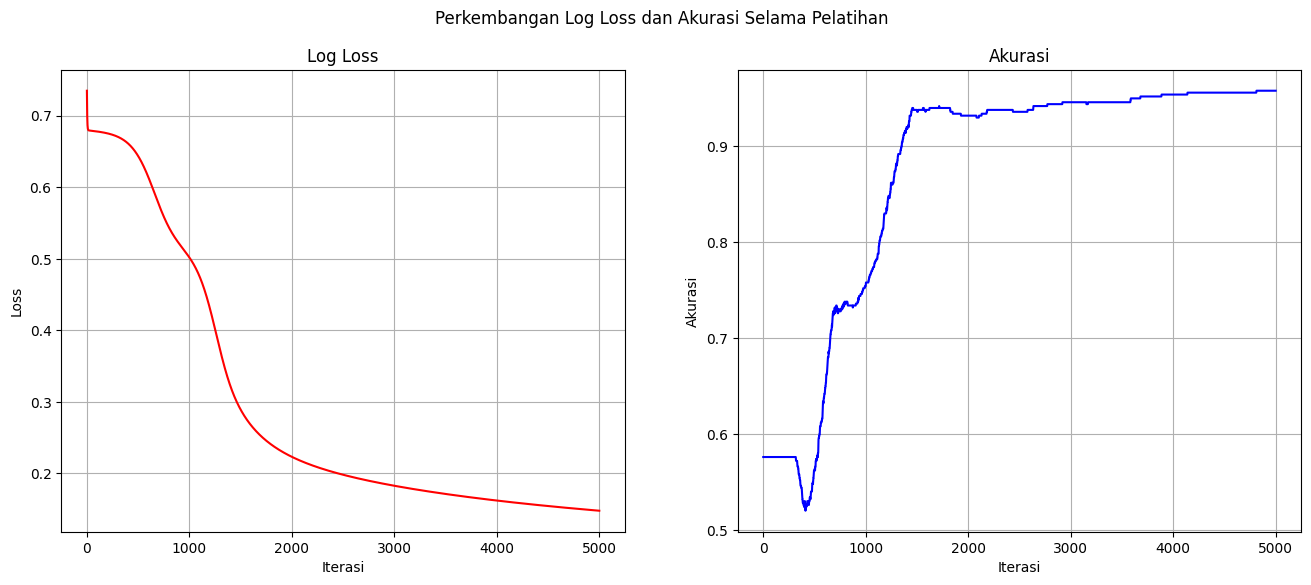

In [9]:
# Atur seed agar hasil dapat direproduksi
np.random.seed(1241)

# Inisialisasi parameter
input_dim = 3 # 2 fitur + 1 bias
hidden_dim = 4
output_dim = 1

W_1 = np.random.uniform(-1, 1, size=(input_dim, hidden_dim))
W_2 = np.random.uniform(-1, 1, size=(hidden_dim))

num_iter = 5000
learning_rate = 0.001

loss_vals, accuracies = [], []

print("Memulai Pelatihan...")

for i in range(num_iter):
    # 1. Forward Pass & Gradien
    y_pred, (grad_W1, grad_W2) = forward_pass(x_mat_full, y, W_1, W_2)
    
    # 2. Update Bobot (Gradient Descent)
    W_1 = W_1 - learning_rate * grad_W1
    W_2 = W_2 - learning_rate * grad_W2
    
    # 3. Catat Loss dan Akurasi
    curr_loss = loss_fn(y, y_pred)
    loss_vals.append(curr_loss)
    
    # Prediksi dianggap benar jika probabilitas >= 0.5
    acc = np.sum((y_pred >= 0.5) == y) / num_obs
    accuracies.append(acc)

    if (i % 500 == 0):
        print(f'Iterasi {i:4d} | Loss: {curr_loss:.4f} | Akurasi: {acc:.4f}')

print("Pelatihan Selesai.")
plot_loss_accuracy(loss_vals, accuracies)

## Visualisasi Hasil


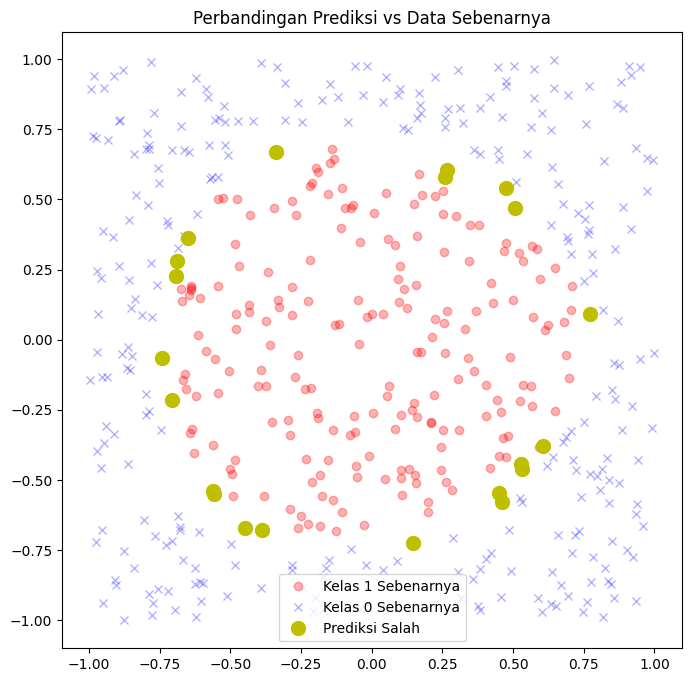

In [10]:
# Hitung prediksi akhir
final_pred, _ = forward_pass(x_mat_full, y, W_1, W_2)
y_final = (final_pred >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_mat_full[y==1, 0], x_mat_full[y==1, 1], 'ro', label='Kelas 1 Sebenarnya', alpha=0.3)
ax.plot(x_mat_full[y==0, 0], x_mat_full[y==0, 1], 'bx', label='Kelas 0 Sebenarnya', alpha=0.3)

# Tandai prediksi yang salah dengan warna kuning
mistakes = (y_final != y)
ax.plot(x_mat_full[mistakes, 0], x_mat_full[mistakes, 1], 'yo', label='Prediksi Salah', markersize=10)

ax.set_title("Perbandingan Prediksi vs Data Sebenarnya")
ax.legend()
plt.show()

### Pertanyaan untuk Diskusi
1. Pola mana yang paling sulit dipelajari oleh jaringan? Mengapa?
2. Apa yang terjadi jika Anda meningkatkan jumlah node di *hidden layer* (misal: dari 4 menjadi 10)?
3. Cobalah ganti `learning_rate` menjadi `0.1`. Apakah model masih bisa konvergen?
4. Bagaimana pengaruh penambahan jumlah iterasi terhadap akurasi akhir?

### Kesimpulan

Dalam lab ini, kita telah mempelajari:
1. Bagaimana alur matematika dari algoritma **Backpropagation**.
2. Implementasi manual *forward pass* dan *backward pass* menggunakan **NumPy**.
3. Pentingnya inisialisasi bobot dan pemilihan *learning rate* yang tepat.
4. Bagaimana jaringan saraf belajar untuk membentuk batas keputusan (*decision boundary*) pada data yang tidak linear.

## Penulis

[Roxanne Li](https://www.linkedin.com/in/roxanne-li/) adalah magang Data Science di IBM Skills Network.

Copyright © 2022 IBM Corporation. All rights reserved.